# Detecting Exoplanets 

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Load data

In [17]:
exoplanet_df = pd.read_csv("exoplanet_dataset.csv")
print(exoplanet_df.shape)
exoplanet_df.head()


(9564, 49)


,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,koi_time0bk_err2,koi_impact,koi_impact_err1,koi_impact_err2,koi_duration,koi_duration_err1,koi_duration_err2,koi_depth,koi_depth_err1,koi_depth_err2,koi_prad,koi_prad_err1,koi_prad_err2,koi_teq,koi_teq_err1,koi_teq_err2,koi_insol,koi_insol_err1,koi_insol_err2,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_steff_err1,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,NaN,NaN,93.59,29.45,-16.65,35.8,1.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,NaN,NaN,9.11,2.87,-1.62,25.8,2.0,q1_q17_dr25_tce,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,NaN,NaN,39.30,31.04,-10.49,76.3,1.0,q1_q17_dr25_tce,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,NaN,NaN,891.96,668.95,-230.35,505.6,1.0,q1_q17_dr25_tce,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,NaN,NaN,926.16,874.33,-314.24,40.9,1.0,q1_q17_dr25_tce,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


## 3. Initial overview

In [18]:
exoplanet_df.info()

exoplanet_df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              9564 non-null   int64  
 1   kepoi_name         9564 non-null   object 
 2   kepler_name        2673 non-null   object 
 3   koi_disposition    9564 non-null   object 
 4   koi_pdisposition   9564 non-null   object 
 5   koi_score          8054 non-null   float64
 6   koi_fpflag_nt      9564 non-null   int64  
 7   koi_fpflag_ss      9564 non-null   int64  
 8   koi_fpflag_co      9564 non-null   int64  
 9   koi_fpflag_ec      9564 non-null   int64  
 10  koi_period         9564 non-null   float64
 11  koi_period_err1    9110 non-null   float64
 12  koi_period_err2    9110 non-null   float64
 13  koi_time0bk        9564 non-null   float64
 14  koi_time0bk_err1   9110 non-null   float64
 15  koi_time0bk_err2   9110 non-null   float64
 16  koi_impact         9201 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
kepid,9564.0,NaN,NaN,NaN,7690628.327373,2653459.080974,757450.0,5556034.25,7906892.0,9873066.5,12935144.0
kepoi_name,9564,9564,K00752.01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kepler_name,2673,2673,Kepler-227 b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_disposition,9564,3,FALSE POSITIVE,4839,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_pdisposition,9564,2,FALSE POSITIVE,4847,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_score,8054.0,NaN,NaN,NaN,0.480829,0.476928,0.0,0.0,0.334,0.998,1.0
koi_fpflag_nt,9564.0,NaN,NaN,NaN,0.208595,4.76729,0.0,0.0,0.0,0.0,465.0
koi_fpflag_ss,9564.0,NaN,NaN,NaN,0.232748,0.422605,0.0,0.0,0.0,0.0,1.0
koi_fpflag_co,9564.0,NaN,NaN,NaN,0.197512,0.398142,0.0,0.0,0.0,0.0,1.0
koi_fpflag_ec,9564.0,NaN,NaN,NaN,0.120033,0.325018,0.0,0.0,0.0,0.0,1.0


In [19]:
# For an easier comprehension, we will rename the columns into their description.

exoplanet_df = exoplanet_df.rename(columns={'kepid':'KepID',
'kepoi_name':'KOIName',
'kepler_name':'KeplerName',
'koi_disposition':'ExoplanetArchiveDisposition',
'koi_pdisposition':'DispositionUsingKeplerData',
'koi_score':'DispositionScore',
'koi_fpflag_nt':'NotTransit-LikeFalsePositiveFlag',
'koi_fpflag_ss':'koi_fpflag_ss',
'koi_fpflag_co':'CentroidOffsetFalsePositiveFlag',
'koi_fpflag_ec':'EphemerisMatchIndicatesContaminationFalsePositiveFlag',
'koi_period':'OrbitalPeriod, days',
'koi_period_err1':'OrbitalPeriodUpperUnc, days',
'koi_period_err2':'OrbitalPeriodLowerUnc, days',
'koi_time0bk':'TransitEpoch, BKJD',
'koi_time0bk_err1':'TransitEpochUpperUnc, BKJD',
'koi_time0bk_err2':'TransitEpochLowerUnc, BKJD',
'koi_impact':'ImpactParamete',
'koi_impact_err1':'ImpactParameterUpperUnc',
'koi_impact_err2':'ImpactParameterLowerUnc',
'koi_duration':'TransitDuration, hrs',
'koi_duration_err1':'TransitDurationUpperUnc, hrs',
'koi_duration_err2':'TransitDurationLowerUnc, hrs',
'koi_depth':'TransitDepth, ppm',
'koi_insol':'InsolationFlux, Earthflux',
'koi_insol_err1':'InsolationFluxUpperUnc, Earthflux',
'koi_insol_err2':'InsolationFluxLowerUnc, Earthflux',
'koi_model_snr':'TransitSignal-to-Noise',
'koi_tce_plnt_num':'TCEPlanetNumber',
'koi_tce_delivname':'TCEDeliver',
'koi_steff':'StellarEffectiveTemperature, K',
'koi_steff_err1':'StellarEffectiveTemperatureUpperUnc, K',
'koi_steff_err2':'StellarEffectiveTemperatureLowerUnc, K',
'koi_depth_err1':'TransitDepthUpperUnc, ppm',
'koi_depth_err2':'TransitDepthLowerUnc, ppm',
'koi_prad':'PlanetaryRadius, Earthradii',
'koi_prad_err1':'PlanetaryRadiusUpperUnc, Earthradii',
'koi_prad_err2':'PlanetaryRadiusLowerUnc, Earthradii',
'koi_teq':'EquilibriumTemperature, K',
'koi_teq_err1':'EquilibriumTemperatureUpperUnc, K',
'koi_teq_err2':'EquilibriumTemperatureLowerUnc, K',
'koi_slogg':'StellarSurfaceGravity, log10(cm/s^2)',
'koi_slogg_err1':'StellarSurfaceGravityUpperUnc, log10(cm/s^2)',
'koi_slogg_err2':'StellarSurfaceGravityLowerUnc, log10(cm/s^2)',
'koi_srad':'StellarRadius, Solarradii',
'koi_srad_err1':'StellarRadiusUpperUnc, Solarradii',
'koi_srad_err2':'StellarRadiusLowerUnc, Solarradii',
'ra':'RA, decimaldegrees',
'dec':'Dec, decimaldegrees',
'koi_kepmag':'Kepler-band, mag'
})

## 4. Missing values analysis

We first compute the percentage of missing values for each column.

In [20]:
missing_percentage = (exoplanet_df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({"missing_percentage": missing_percentage})
missing_df

,missing_percentage
"EquilibriumTemperatureLowerUnc, K",100.000000
"EquilibriumTemperatureUpperUnc, K",100.000000
KeplerName,72.051443
DispositionScore,15.788373
"StellarEffectiveTemperatureLowerUnc, K",5.050188
"StellarRadiusLowerUnc, Solarradii",4.893350
"StellarRadiusUpperUnc, Solarradii",4.893350
"StellarSurfaceGravityLowerUnc, log10(cm/s^2)",4.893350
"StellarSurfaceGravityUpperUnc, log10(cm/s^2)",4.893350
"StellarEffectiveTemperatureUpperUnc, K",4.893350


In [21]:
# columns with 100% missing values
cols_100_missing = ['EquilibriumTemperatureUpperUnc, K', 'EquilibriumTemperatureLowerUnc, K']

# irrelevant identifiers / name columns
cols_irrelevant = ['KepID', "KOIName", "KeplerName", "TCEDeliver"]

exoplanet_clean = exoplanet_df.drop(columns=cols_100_missing + cols_irrelevant)

print(exoplanet_clean.shape)
exoplanet_clean.head()

(9564, 43)


,ExoplanetArchiveDisposition,DispositionUsingKeplerData,DispositionScore,NotTransit-LikeFalsePositiveFlag,koi_fpflag_ss,CentroidOffsetFalsePositiveFlag,EphemerisMatchIndicatesContaminationFalsePositiveFlag,"OrbitalPeriod, days","OrbitalPeriodUpperUnc, days","OrbitalPeriodLowerUnc, days","TransitEpoch, BKJD","TransitEpochUpperUnc, BKJD","TransitEpochLowerUnc, BKJD",ImpactParamete,ImpactParameterUpperUnc,ImpactParameterLowerUnc,"TransitDuration, hrs","TransitDurationUpperUnc, hrs","TransitDurationLowerUnc, hrs","TransitDepth, ppm","TransitDepthUpperUnc, ppm","TransitDepthLowerUnc, ppm","PlanetaryRadius, Earthradii","PlanetaryRadiusUpperUnc, Earthradii","PlanetaryRadiusLowerUnc, Earthradii","EquilibriumTemperature, K","InsolationFlux, Earthflux","InsolationFluxUpperUnc, Earthflux","InsolationFluxLowerUnc, Earthflux",TransitSignal-to-Noise,TCEPlanetNumber,"StellarEffectiveTemperature, K","StellarEffectiveTemperatureUpperUnc, K","StellarEffectiveTemperatureLowerUnc, K","StellarSurfaceGravity, log10(cm/s^2)","StellarSurfaceGravityUpperUnc, log10(cm/s^2)","StellarSurfaceGravityLowerUnc, log10(cm/s^2)","StellarRadius, Solarradii","StellarRadiusUpperUnc, Solarradii","StellarRadiusLowerUnc, Solarradii","RA, decimaldegrees","Dec, decimaldegrees","Kepler-band, mag"
0,CONFIRMED,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,0.002160,-0.002160,0.146,0.318,-0.146,2.95750,0.08190,-0.08190,615.8,19.5,-19.5,2.26,0.26,-0.15,793.0,93.59,29.45,-16.65,35.8,1.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CONFIRMED,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,0.003520,-0.003520,0.586,0.059,-0.443,4.50700,0.11600,-0.11600,874.8,35.5,-35.5,2.83,0.32,-0.19,443.0,9.11,2.87,-1.62,25.8,2.0,5455.0,81.0,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,CANDIDATE,CANDIDATE,0.000,0,0,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,0.000581,-0.000581,0.969,5.126,-0.077,1.78220,0.03410,-0.03410,10829.0,171.0,-171.0,14.60,3.92,-1.31,638.0,39.30,31.04,-10.49,76.3,1.0,5853.0,158.0,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,0.000115,-0.000115,1.276,0.115,-0.092,2.40641,0.00537,-0.00537,8079.2,12.8,-12.8,33.46,8.50,-2.83,1395.0,891.96,668.95,-230.35,505.6,1.0,5805.0,157.0,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,CONFIRMED,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,0.001130,-0.001130,0.701,0.235,-0.478,1.65450,0.04200,-0.04200,603.3,16.9,-16.9,2.75,0.88,-0.35,1406.0,926.16,874.33,-314.24,40.9,1.0,6031.0,169.0,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [22]:
# encode disposition columns:

status_map = {
    "FALSE POSITIVE": 0,
    "CANDIDATE": 1,
    "CONFIRMED": 2
}

exoplanet_clean["KeplerDispositionStatus"] = exoplanet_clean["DispositionUsingKeplerData"].map(status_map)
exoplanet_clean["ArchiveDispositionStatus"] = exoplanet_clean["ExoplanetArchiveDisposition"].map(status_map)

exoplanet_clean = exoplanet_clean.drop(columns=["DispositionUsingKeplerData", "ExoplanetArchiveDisposition"])

exoplanet_clean[["KeplerDispositionStatus", "ArchiveDispositionStatus"]].head()

,KeplerDispositionStatus,ArchiveDispositionStatus
0,1,2
1,1,2
2,1,1
3,0,0
4,1,2


In [23]:
# target check:

print(exoplanet_clean["KeplerDispositionStatus"].value_counts(dropna=False))
print(exoplanet_clean["ArchiveDispositionStatus"].value_counts(dropna=False))

KeplerDispositionStatus
0    4847
1    4717
Name: count, dtype: int64
ArchiveDispositionStatus
0    4839
2    2671
1    2054
Name: count, dtype: int64


## 6. Outlier analysis using IQR

First we count outliers and then decide if we want to remove them.

In [24]:
numeric_cols = exoplanet_clean.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    series = exoplanet_clean[col].dropna()
    if len(series) == 0:
        continue
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    outlier_summary.append({
        "feature": col,
        "outliers": outliers,
        "total": len(series),
        "percentage": (outliers / len(series)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values(by="percentage", ascending=False)
outlier_df

,feature,outliers,total,percentage
2,koi_fpflag_ss,2226,9564,23.274780
3,CentroidOffsetFalsePositiveFlag,1889,9564,19.751150
17,"TransitDepth, ppm",1798,9201,19.541354
21,"PlanetaryRadiusUpperUnc, Earthradii",1716,9201,18.650147
6,"OrbitalPeriodUpperUnc, days",1650,9110,18.111965
7,"OrbitalPeriodLowerUnc, days",1650,9110,18.111965
27,TransitSignal-to-Noise,1600,9201,17.389414
25,"InsolationFluxUpperUnc, Earthflux",1536,9243,16.617981
5,"OrbitalPeriod, days",1567,9564,16.384358
26,"InsolationFluxLowerUnc, Earthflux",1483,9243,16.044574


#### Interpretations

The IQR-based outlier analysis identified many extreme values, especially in binary flag columns and several scientific measurement columns. For binary variables, these are not true outliers but a consequence of the method being less suitable for 0/1 features. For the continuous astronomical features, extreme values may reflect real observations rather than errors. Therefore, I decided not to remove outliers at this stage. Instead, I kept them and later considered transformations for strongly skewed variables.

In [25]:
print("Original shape:", exoplanet_clean.shape)
print("Shape after dropna:", exoplanet_clean.dropna().shape)
print("Rows removed:", exoplanet_clean.shape[0] - exoplanet_clean.dropna().shape[0])

Original shape: (9564, 43)
Shape after dropna: (7803, 43)
Rows removed: 1761


In [26]:
# separate target-related columns before imputation
target_cols = ["KeplerDispositionStatus", "ArchiveDispositionStatus"]

feature_cols = [col for col in exoplanet_clean.columns if col not in target_cols]

# numeric feature columns
numeric_feature_cols = exoplanet_clean[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

 # note: keep missing values here to avoid leakage; imputer will be fit on training split only
missing_before_split = exoplanet_clean[numeric_feature_cols].isnull().sum().sort_values(ascending=False)
print(missing_before_split.head(10))
print("Remaining missing values before split:", exoplanet_clean.isnull().sum().sum())

DispositionScore                                1510
StellarEffectiveTemperatureLowerUnc, K           483
StellarSurfaceGravityLowerUnc, log10(cm/s^2)     468
StellarSurfaceGravityUpperUnc, log10(cm/s^2)     468
StellarEffectiveTemperatureUpperUnc, K           468
StellarRadiusUpperUnc, Solarradii                468
StellarRadiusLowerUnc, Solarradii                468
OrbitalPeriodUpperUnc, days                      454
OrbitalPeriodLowerUnc, days                      454
TransitDepthUpperUnc, ppm                        454
dtype: int64
Remaining missing values before split: 13813


## 11. Correlation analysis

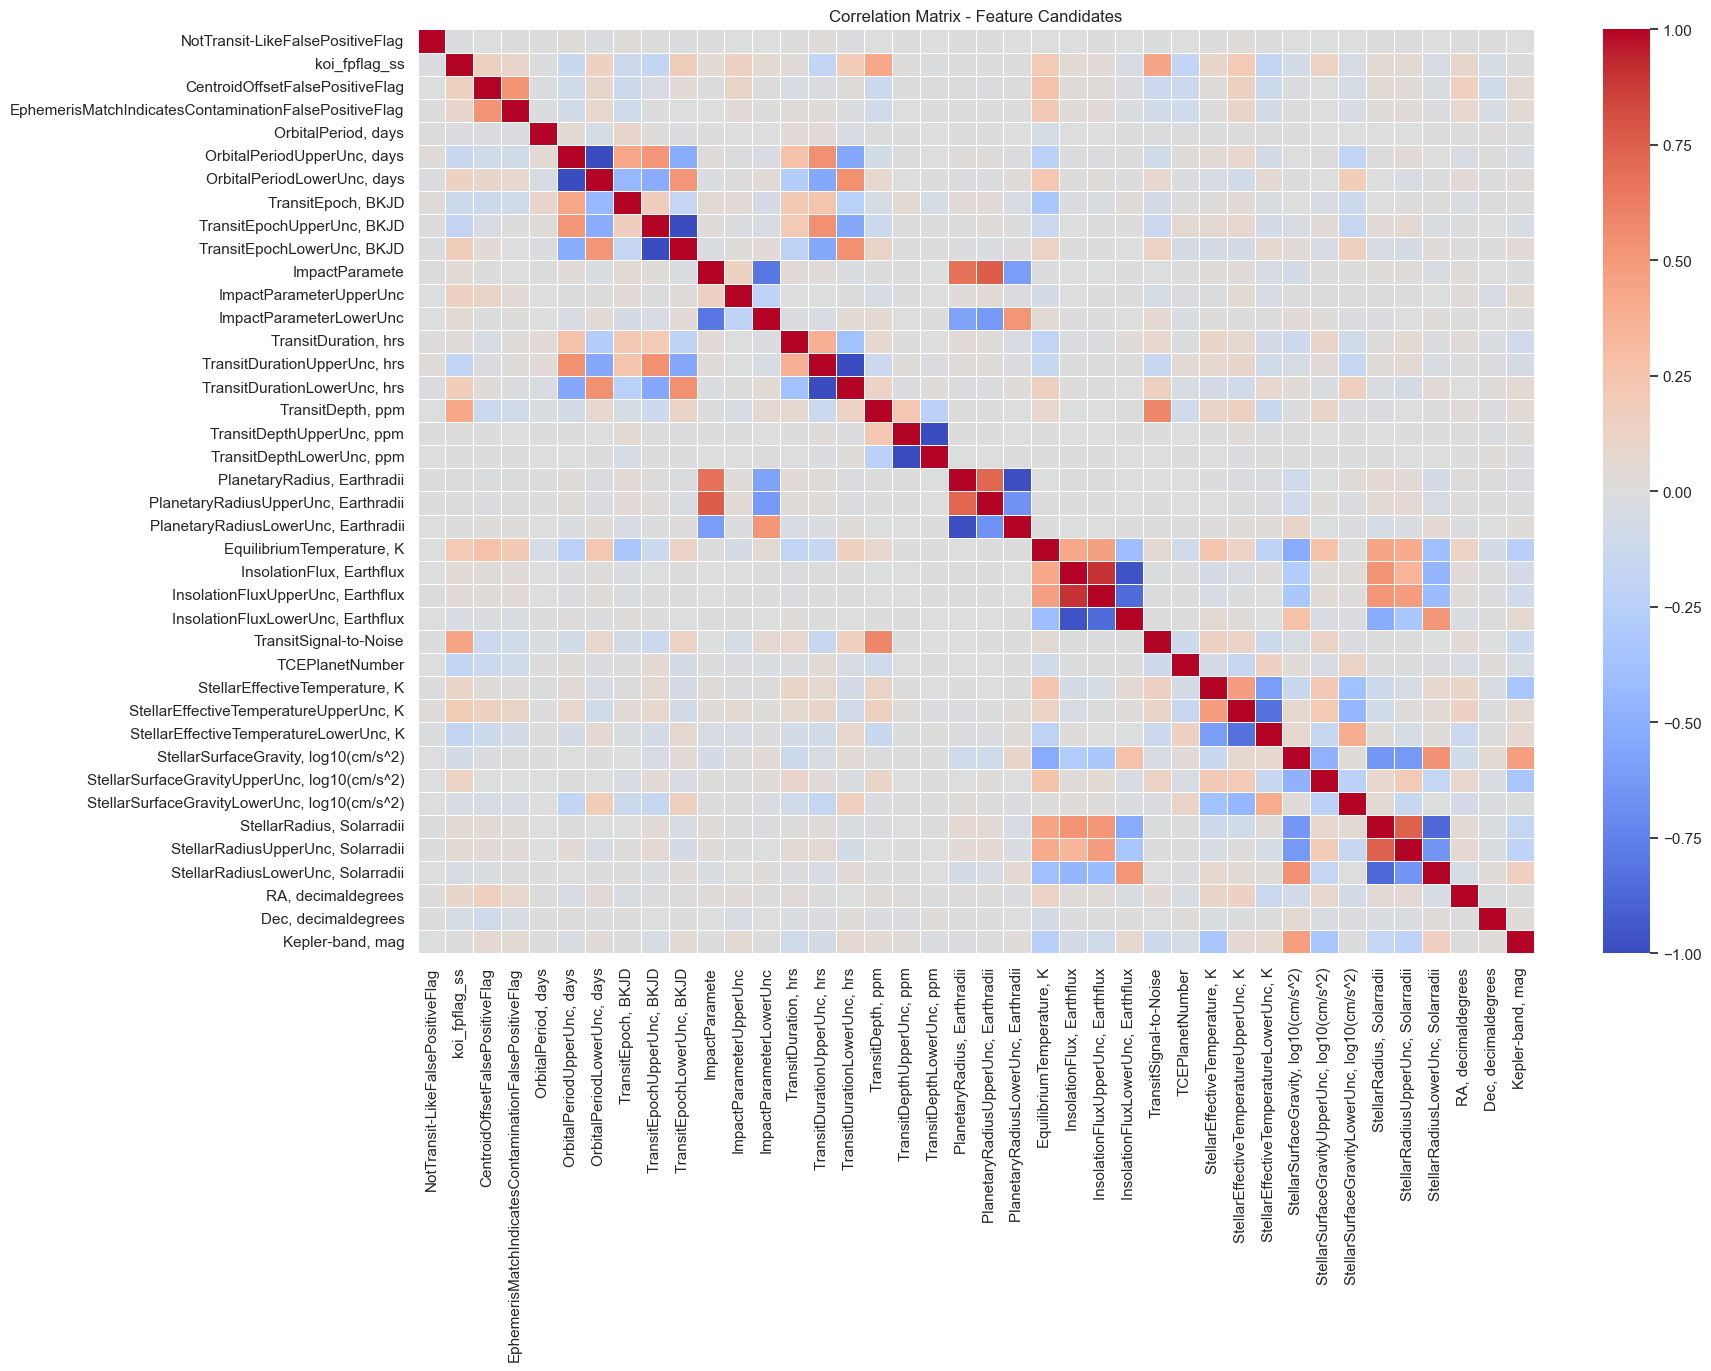

In [27]:
# columns that will not be used as model features
exclude_cols = ["DispositionScore", "KeplerDispositionStatus", "ArchiveDispositionStatus"]

feature_corr_df = exoplanet_clean.drop(columns=exclude_cols, errors="ignore")

correlation_matrix = feature_corr_df.corr()

plt.figure(figsize=(18,12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix - Feature Candidates")
plt.show()

In [28]:
# Stronger correlations

corr_pairs = correlation_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs = corr_pairs.sort_values(ascending=False)

# remove duplicate pairs
corr_pairs = corr_pairs.reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["pair_key"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates(subset="pair_key").drop(columns="pair_key")

# show strongest correlations

high_corr_pairs = corr_pairs[corr_pairs["correlation"] > 0.95]
high_corr_pairs.head(20)

,feature_1,feature_2,correlation
0,"PlanetaryRadiusLowerUnc, Earthradii","PlanetaryRadius, Earthradii",0.987628
2,"InsolationFlux, Earthflux","InsolationFluxLowerUnc, Earthflux",0.966618


In [29]:
# drop those with high correlation to avoid multicollinearity issues in modeling

cols_high_corr_to_drop = [
    "PlanetaryRadiusLowerUnc, Earthradii",
    "InsolationFluxLowerUnc, Earthflux"
]

exoplanet_model = exoplanet_clean.drop(columns=cols_high_corr_to_drop)

print(exoplanet_model.shape)

(9564, 41)


### Prepare X & y

In [30]:
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

final_imputer = SimpleImputer(strategy="median")
X_train_val_imputed = final_imputer.fit_transform(X_train_val)

final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val_imputed)

NameError: name 'X_train' is not defined

## Train / validation / test split

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train: (6120, 38)
X_val: (1531, 38)
X_test: (1913, 38)

Train target distribution:
KeplerDispositionStatus
0    0.506699
1    0.493301
Name: proportion, dtype: float64

Validation target distribution:
KeplerDispositionStatus
0    0.506858
1    0.493142
Name: proportion, dtype: float64

Test target distribution:
KeplerDispositionStatus
0    0.507057
1    0.492943
Name: proportion, dtype: float64


## Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val)

## Logistic Regression tuning

In [ ]:
log_results = []

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    log_model = LogisticRegression(C=C, max_iter=5000, random_state=42)
    log_model.fit(X_train_scaled, y_train)

    y_train_pred = log_model.predict(X_train_scaled)
    y_val_pred = log_model.predict(X_val_scaled)

    log_results.append({
        "C": C,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_precision": precision_score(y_train, y_train_pred, average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, y_train_pred, average="weighted", zero_division=0),
        "train_f1": f1_score(y_train, y_train_pred, average="weighted", zero_division=0),
        "val_accuracy": accuracy_score(y_val, y_val_pred),
        "val_precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
        "val_f1": f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    })

    log_results_df = pd.DataFrame(log_results).sort_values(by="val_f1", ascending=False)
log_results_df

,C,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1
2,0.100,0.986275,0.986478,0.986275,0.986275,0.994121,0.994143,0.994121,0.994122
1,0.010,0.984641,0.984899,0.984641,0.984641,0.992815,0.992857,0.992815,0.992815
3,1.000,0.986275,0.986465,0.986275,0.986275,0.992815,0.992857,0.992815,0.992815
4,10.000,0.986438,0.986622,0.986438,0.986438,0.991509,0.991578,0.991509,0.991509
5,100.000,0.986601,0.986780,0.986601,0.986602,0.991509,0.991578,0.991509,0.991509
0,0.001,0.970915,0.971334,0.970915,0.970914,0.981711,0.981877,0.981711,0.981712


In [ ]:
best_log_C = log_results_df.iloc[0]["C"]
print("Best Logistic Regression C:", best_log_C)

Best Logistic Regression C: 0.1


In [ ]:
best_log_model = LogisticRegression(C=best_log_C, max_iter=5000, random_state=42)
best_log_model.fit(X_train_scaled, y_train)

y_train_pred_log = best_log_model.predict(X_train_scaled)
y_val_pred_log = best_log_model.predict(X_val_scaled)

print("Logistic Regression - Train metrics")
print("Accuracy:", accuracy_score(y_train, y_train_pred_log))
print("Precision:", precision_score(y_train, y_train_pred_log, average="weighted", zero_division=0))
print("Recall:", recall_score(y_train, y_train_pred_log, average="weighted", zero_division=0))
print("F1-score:", f1_score(y_train, y_train_pred_log, average="weighted", zero_division=0))

print("\nLogistic Regression - Validation metrics")
print("Accuracy:", accuracy_score(y_val, y_val_pred_log))
print("Precision:", precision_score(y_val, y_val_pred_log, average="weighted", zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred_log, average="weighted", zero_division=0))
print("F1-score:", f1_score(y_val, y_val_pred_log, average="weighted", zero_division=0))

Logistic Regression - Train metrics
Accuracy: 0.9862745098039216
Precision: 0.976306394027913
Recall: 0.9963564094070885
F1-score: 0.9862295081967213

Logistic Regression - Validation metrics
Accuracy: 0.9941214892227302
Precision: 0.9907894736842106
Recall: 0.9973509933774835
F1-score: 0.994059405940594


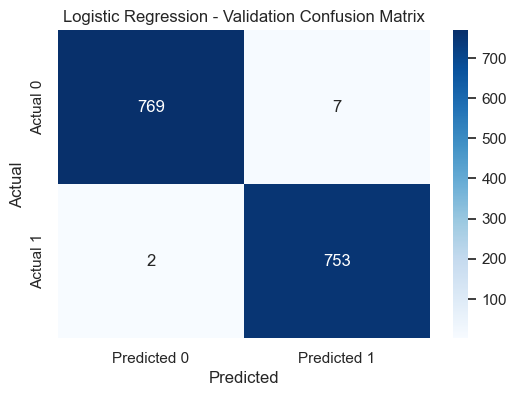

In [ ]:
# Confusion matrix for validation set
class_labels = sorted(y.unique())
cm_log = confusion_matrix(y_val, y_val_pred_log, labels=class_labels)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Interpretation

Logistic Regression achieved very high validation performance. However, some features in the dataset are false-positive flags that are likely strongly related to how the target label was assigned. Therefore, the results should be interpreted with caution, as the model may partially rely on proxy information rather than only on physical measurements.

### SVM tuning

In [ ]:
svm_results = []

for C in [0.01, 0.1, 1, 10]:
    for kernel in ["linear", "rbf"]:
        svm_model = SVC(C=C, kernel=kernel, random_state=42)
        svm_model.fit(X_train_scaled, y_train)

        y_train_pred = svm_model.predict(X_train_scaled)
        y_val_pred = svm_model.predict(X_val_scaled)

        svm_results.append({
            "C": C, 
            "kernel": kernel,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "train_precision": precision_score(y_train, y_train_pred, average="weighted", zero_division=0),
            "train_recall": recall_score(y_train, y_train_pred, average="weighted", zero_division=0),
            "train_f1": f1_score(y_train, y_train_pred, average="weighted", zero_division=0),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_precision": precision_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "val_recall": recall_score(y_val, y_val_pred, average="weighted", zero_division=0),
            "val_f1": f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
        })

svm_results_df = pd.DataFrame(svm_results).sort_values(by="val_f1", ascending=False)
svm_results_df

,C,kernel,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,0.01,linear,0.986765,0.976021,0.997681,0.986732,0.993468,0.989488,0.997351,0.993404
2,0.10,linear,0.986765,0.976021,0.997681,0.986732,0.993468,0.989488,0.997351,0.993404
4,1.00,linear,0.986765,0.976021,0.997681,0.986732,0.993468,0.989488,0.997351,0.993404
6,10.00,linear,0.986765,0.976021,0.997681,0.986732,0.993468,0.989488,0.997351,0.993404
5,1.00,rbf,0.986765,0.977258,0.996356,0.986715,0.986283,0.988032,0.984106,0.986065
7,10.00,rbf,0.990033,0.981759,0.998344,0.989982,0.983018,0.986649,0.978808,0.982713
3,0.10,rbf,0.973856,0.976977,0.969858,0.973404,0.979752,0.990515,0.968212,0.979236
1,0.01,rbf,0.948693,0.971747,0.922822,0.946653,0.943174,0.985465,0.898013,0.939709


In [ ]:
best_svm_C = svm_results_df.iloc[0]["C"]
best_svm_kernel = svm_results_df.iloc[0]["kernel"]

print("Best SVM C:", best_svm_C)
print("Best SVM kernel:", best_svm_kernel)

Best SVM C: 0.01
Best SVM kernel: linear


In [ ]:
best_svm_model = SVC(C=best_svm_C, kernel=best_svm_kernel, random_state=42)
best_svm_model.fit(X_train_scaled, y_train)

y_train_pred_svm = best_svm_model.predict(X_train_scaled)
y_val_pred_svm = best_svm_model.predict(X_val_scaled)

print("SVM - Train metrics")
print("Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("Precision:", precision_score(y_train, y_train_pred_svm, average="weighted", zero_division=0))
print("Recall:", recall_score(y_train, y_train_pred_svm, average="weighted", zero_division=0))
print("F1-Score:", f1_score(y_train, y_train_pred_svm, average="weighted", zero_division=0))

print("\nSVM - Validation metrics")
print("Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Precision:", precision_score(y_val, y_val_pred_svm, average="weighted", zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred_svm, average="weighted", zero_division=0))
print("F1-Score:", f1_score(y_val, y_val_pred_svm, average="weighted", zero_division=0))

SVM - Train metrics
Accuracy: 0.986764705882353
Precision: 0.9760207388204796
Recall: 0.9976813514408744
F1-Score: 0.9867321867321868

SVM - Validation metrics
Accuracy: 0.9934683213585892
Precision: 0.9894875164257556
Recall: 0.9973509933774835
F1-Score: 0.9934036939313984


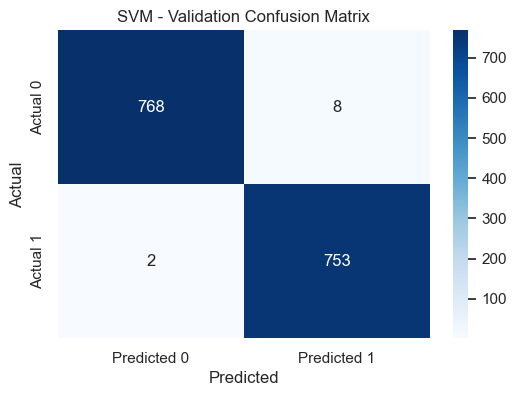

In [ ]:
cm_svm = confusion_matrix(y_val, y_val_pred_svm, labels=class_labels)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("SVM - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Final model

In [ ]:
# final scaling
final_scaler = StandardScaler()
X_train_val_scaled = final_scaler.fit_transform(X_train_val)
X_test_scaled = final_scaler.transform(X_test)

# final Logistic Regression
final_log_model = LogisticRegression(C=best_log_C, max_iter=5000, random_state=42)
final_log_model.fit(X_train_val_scaled, y_train_val)
y_test_pred_log = final_log_model.predict(X_test_scaled)

# final SVM
final_svm_model = SVC(C=best_svm_C, kernel=best_svm_kernel, random_state=42)
final_svm_model.fit(X_train_val_scaled, y_train_val)
y_test_pred_svm = final_svm_model.predict(X_test_scaled)

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(model_name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted", zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, average="weighted", zero_division=0))
    print("F1-score:", f1_score(y_true, y_pred, average="weighted", zero_division=0))
    print()

evaluate_model(y_test, y_test_pred_log, "Logistic Regression - Test set")
evaluate_model(y_test, y_test_pred_svm, "SVM - Test set")

Logistic Regression - Test set
Accuracy: 0.902247778358599
Precision: 0.8655705996131529
Recall: 0.9490986214209968
F1-score: 0.9054122407688416

SVM - Test set
Accuracy: 0.8991113434396236
Precision: 0.8478664192949907
Recall: 0.9692470837751855
F1-score: 0.9045027214250371



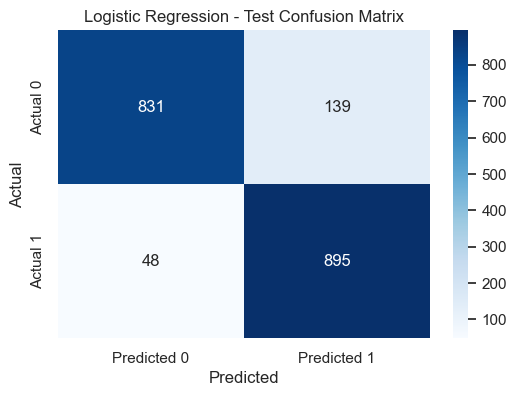

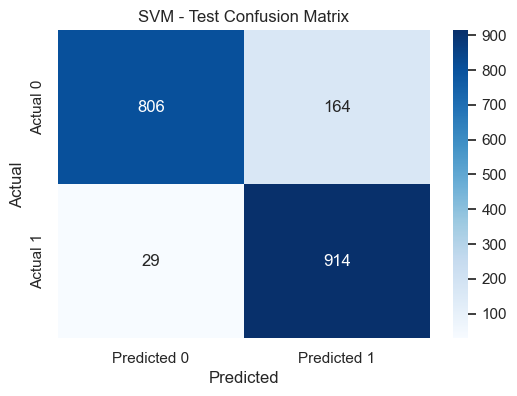

In [ ]:
class_labels_test = sorted(y_test.unique())
cm_log_test = confusion_matrix(y_test, y_test_pred_log, labels=class_labels_test)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_log_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels_test,
    yticklabels=class_labels_test
)
plt.title("Logistic Regression - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_svm_test = confusion_matrix(y_test, y_test_pred_svm, labels=class_labels_test)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels_test,
    yticklabels=class_labels_test
)
plt.title("SVM - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Interpretations

Both models performed extremely well on the validation set, but their performance dropped notably on the test set. This suggests that the validation results were optimistic and that the test set provides a more realistic estimate of generalization performance. Logistic Regression achieved the best overall test performance, with slightly higher accuracy and F1-score than SVM. SVM achieved higher recall and fewer false negatives, but this came at the cost of more false positives and lower precision. Therefore, Logistic Regression was selected as the final model because it provided the best overall balance between precision and recall, while also being simpler and easier to interpret. However, if the main goal were to minimize missed exoplanet candidates, SVM could also be justified due to its higher recall.

### Limitations

One limitation of this analysis is that some preprocessing steps, such as imputation and correlation-based feature filtering, were performed before the final train-validation-test split. In addition, some flag-based features may be strongly related to the target labeling process itself. Therefore, the reported validation performance may have been overly optimistic, and the test set results should be considered the more reliable estimate.